In [16]:
import os
os.chdir("/Users/franciscegoat/mm-rl")
import json
import torch
import importlib.util

from src.envs.env_toy_mm import MMSimulator
from src.ppo.networks import ActorNet, CriticNet
from src.utils.device import get_device
from scripts.train_loop import train_ppo, train_one_episode_ppo
from src.evaluation.rollout import run_one_episode

device = get_device()

[Device] Using mps


In [17]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from copy import deepcopy

In [20]:
eta_grid = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3]
csv_path = "data/raw/toy_lob_non_stationnary_seed42.csv"

def evaluate_policy(env, actor, n_eval=20, device="cpu"):
    pnl_list = []
    inv_list = []
    reward_list = []

    for _ in range(n_eval):
        rollout = run_one_episode(
            env=env,
            actor=actor,
            device=device
        )

        pnl_list.append(rollout["final_pnl"])
        inv_list.append(np.mean(np.abs(rollout["inventory"])))
        reward_list.append(rollout["cum_reward"])

    return {
        "mean_pnl": np.mean(pnl_list),
        "std_pnl": np.std(pnl_list),
        "mean_abs_inventory": np.mean(inv_list),
        "mean_reward": np.mean(reward_list),
    }

In [21]:
results = []

for eta in eta_grid:

    print(f"===== eta_inv = {eta:.1e} =====")

    env = MMSimulator(
        csv_path=csv_path,
        eta_inv=eta,
        eta_terminal=5e-3
    )

    actor = ActorNet(
        state_dim=env.state_dim,
        action_dim=1,   # ou 4 quand tu passes en 4D
        hidden_size=64,
        n_layers=3,
        delta_min=0.001,
        delta_max=0.05
    ).to(device)

    critic = CriticNet(
        state_dim=env.state_dim,
        hidden_size=64,
        n_layers=3
    ).to(device)

    actor_optimizer = torch.optim.Adam(actor.parameters(), lr=3e-4)
    critic_optimizer = torch.optim.Adam(critic.parameters(), lr=1e-3)

    history = train_ppo(
        env=env,
        actor=actor,
        critic=critic,
        actor_optimizer=actor_optimizer,
        critic_optimizer=critic_optimizer,
        device=device,
        gamma=0.99,
        lam=0.95,
        n_episodes=150,
        n_epochs_actor=10,
        n_epochs_critic=10,
        batch_size=64,
        max_steps=200,
        verbose=True
    )

    metrics = evaluate_policy(env, actor, n_eval=25, device=device)

    metrics["eta_inv"] = eta
    results.append(metrics)

===== eta_inv = 1.0e-05 =====
===== eta_inv = 3.0e-05 =====
===== eta_inv = 1.0e-04 =====
===== eta_inv = 3.0e-04 =====
===== eta_inv = 1.0e-03 =====


In [22]:
df = pd.DataFrame(results)
df = df.sort_values("eta_inv")
df

,mean_pnl,std_pnl,mean_abs_inventory,mean_reward,eta_inv
0,1.293506,2.041982,3.3770,0.999626,0.00001
1,1.328332,1.888410,2.9260,0.961936,0.00003
2,1.610672,1.894322,3.0472,0.944477,0.00010
3,1.563869,1.905302,3.0342,0.458851,0.00030
4,1.540315,2.090056,3.2058,-1.932151,0.00100


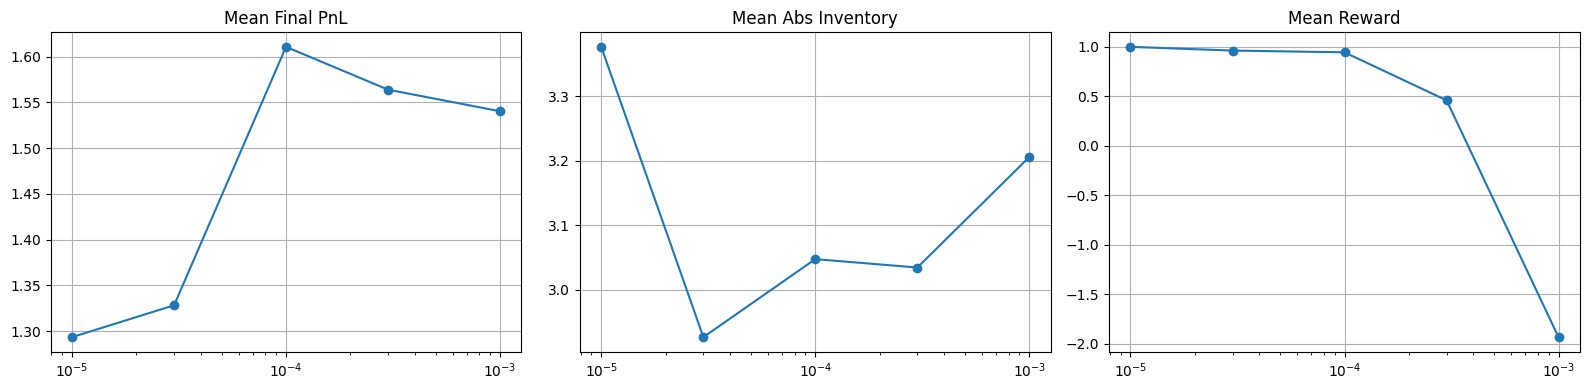

In [23]:
fig, axes = plt.subplots(1,3, figsize=(16,4))

axes[0].semilogx(df["eta_inv"], df["mean_pnl"], marker="o")
axes[0].set_title("Mean Final PnL")
axes[0].grid(True)

axes[1].semilogx(df["eta_inv"], df["mean_abs_inventory"], marker="o")
axes[1].set_title("Mean Abs Inventory")
axes[1].grid(True)

axes[2].semilogx(df["eta_inv"], df["mean_reward"], marker="o")
axes[2].set_title("Mean Reward")
axes[2].grid(True)

plt.tight_layout()
plt.show()